# importing the libraries

In [2]:
import numpy as np      # numpy is used while dealing with arrays and for mathematical calculations
import pandas as pd     # pandas is used for working on the dataframes(tables)
import matplotlib.pyplot as plt     #   visualizing the data
%matplotlib inline
import seaborn as sns


In [3]:
df = pd.read_csv("Diwali Sales Data.csv", encoding= 'unicode_escape') # to avoid encoding error, use 'unicode_escape'

In [4]:
df.shape    # for identifying the dimensions of the created dataframe

(11251, 15)

In [5]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


# Data Cleaning

In [6]:
df.info()   # info() --> it gives full info about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
# drop unrelated/blank columns
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [8]:
# check for null values
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [9]:
df.shape

(11251, 13)

In [10]:
# drop null values
df.dropna(inplace=True)

In [11]:
df.shape

(11239, 13)

In [12]:
# changing the datatype
df['Amount'] = df['Amount'].astype('int')

In [13]:
df['Amount'].dtypes

dtype('int64')

In [14]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [15]:
df.describe()   # describe() method returns description of the data in the dataframe (i.e. count, mean, std, etc)

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


# EDA (EXPLORATORY DATA ANALYSIS)

### Why do EDA
- Model building
- Analysis and reporting
- Validate assumptions
- Handling missing values
- feature engineering
- detecting outliers

#  Univariate Analysis & Bivariate Analysis
- Univariate Analysis (Single Variable Analysis) --> and each column is called the variable, and we perform analysis on each varible independently.
- Bivariate Analysis (Two Variable Analysis)

## Gender

In [16]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [17]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877


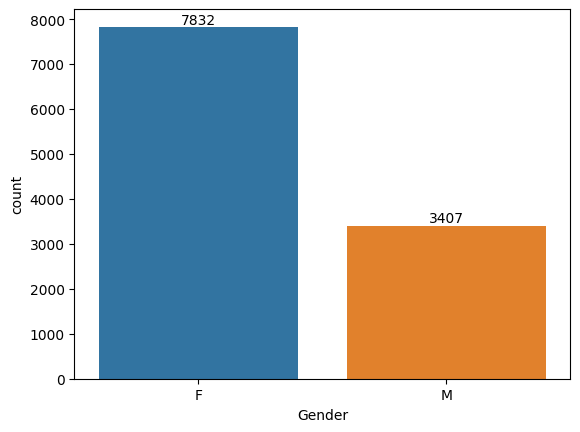

In [18]:
ax = sns.countplot(x = 'Gender', hue='Gender', data = df)

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

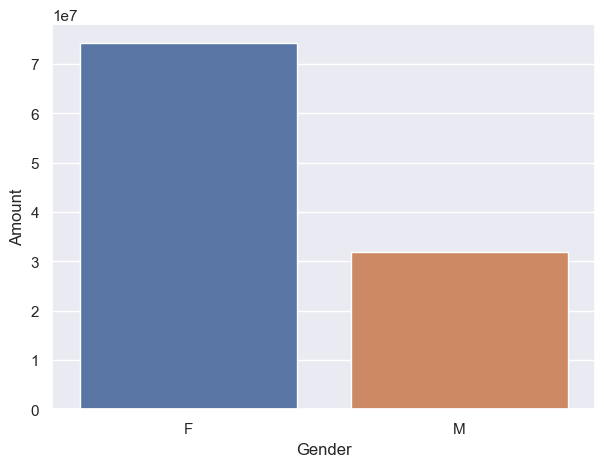

In [19]:
# Gender VS Amount
sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(7,5)})
sns.barplot(x = 'Gender', y = 'Amount', data=sales_gen, hue='Gender')

## conclusion :
*from the above graphs we got to know that most of the buyers are females and even the purchasing power of the female are greater than men*

## Age

In [20]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [21]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877


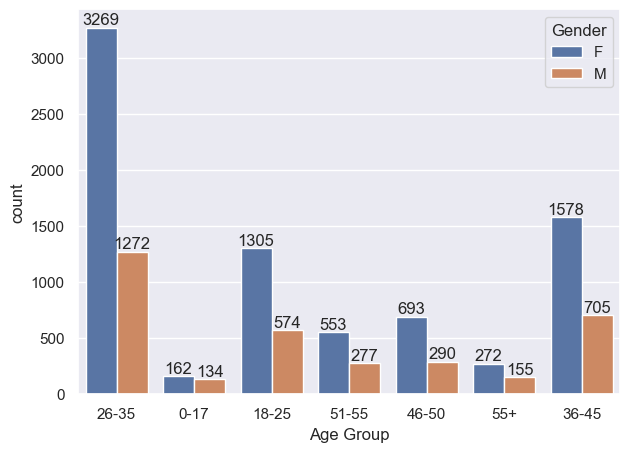

In [22]:
ax = sns.countplot(data= df, x = 'Age Group', hue= 'Gender')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

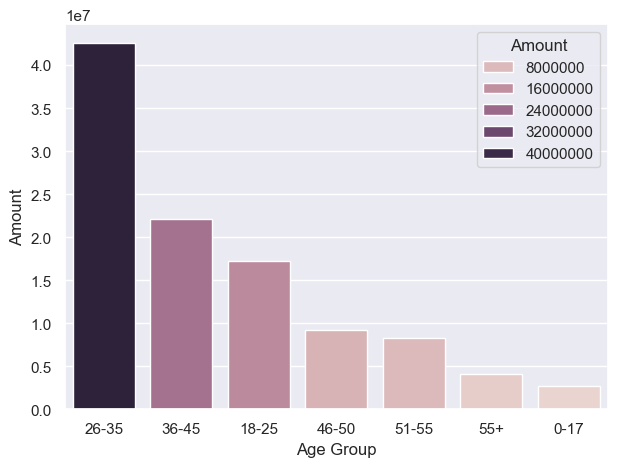

In [23]:
# Total Amount vs Age Group

sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x = 'Age Group', y = 'Amount', data= sales_age, hue= 'Amount')

## conclusion :
*From the above graphs we can see that most of the buyers are of the age group between 26-35 yrs female*

# State

In [24]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [25]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877


<Axes: xlabel='State', ylabel='Orders'>

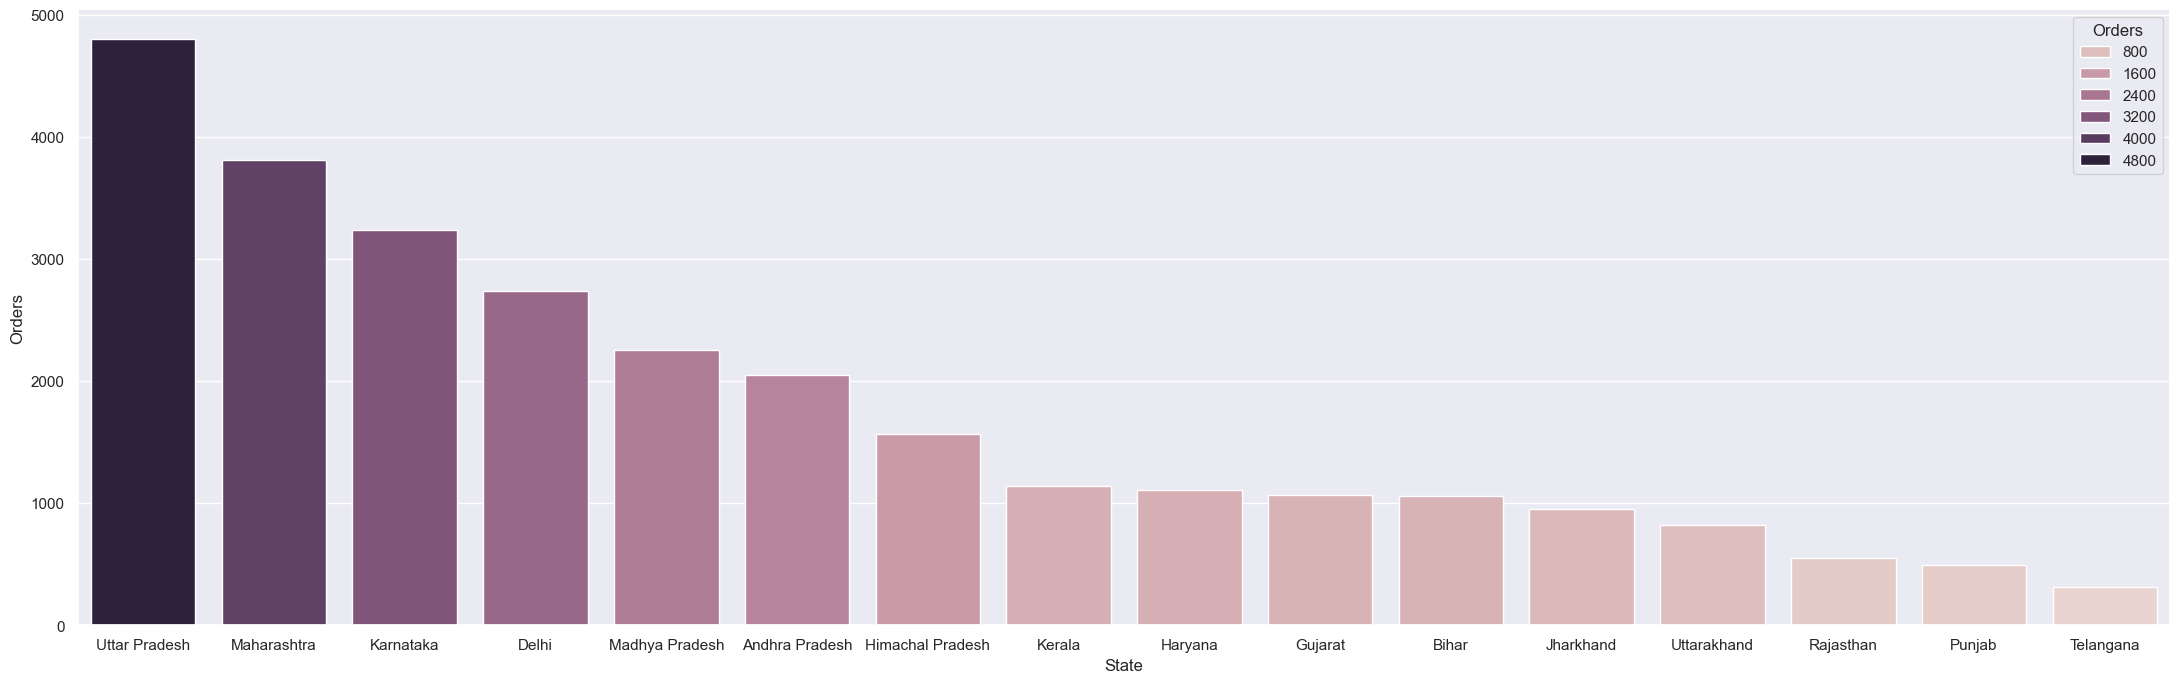

In [26]:
# total number of orders from top 10 states

sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(40)

sns.set(rc={'figure.figsize':(27,8)})
sns.barplot(data = sales_state, x = 'State', y = 'Orders', hue= 'Orders')

<Axes: xlabel='State', ylabel='Amount'>

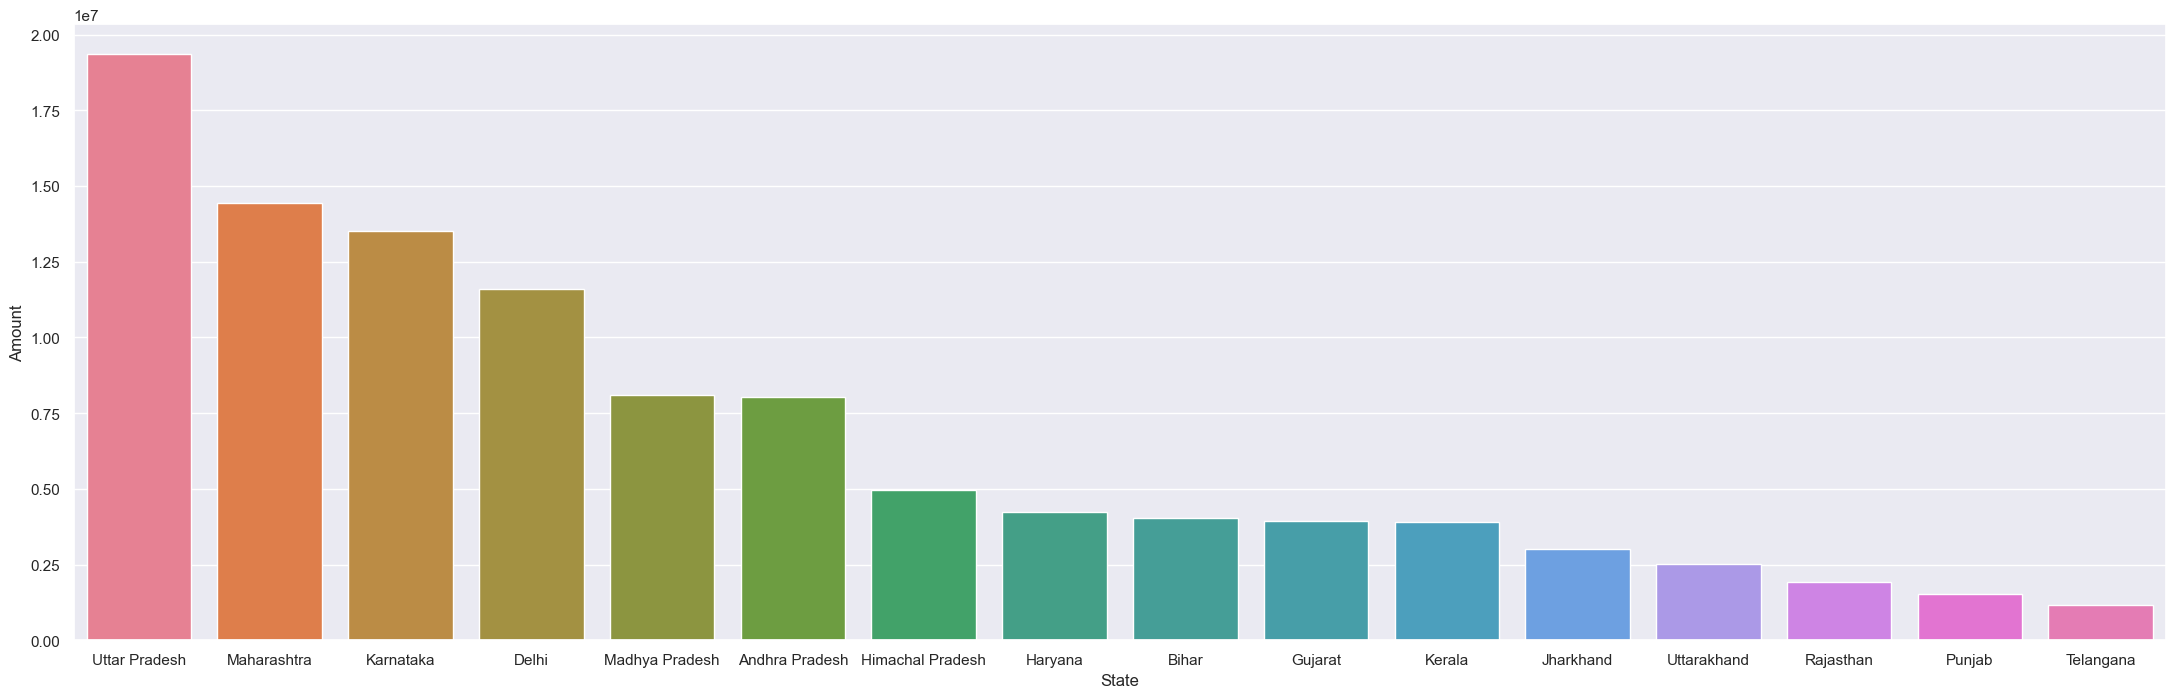

In [27]:
# total amount/sales from top 10 states

sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(27,8)})
sns.barplot(data = sales_state, x = 'State', y = 'Amount', hue= 'State')

## conclusion :
*From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively*

# Marital Status



In [28]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [29]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877


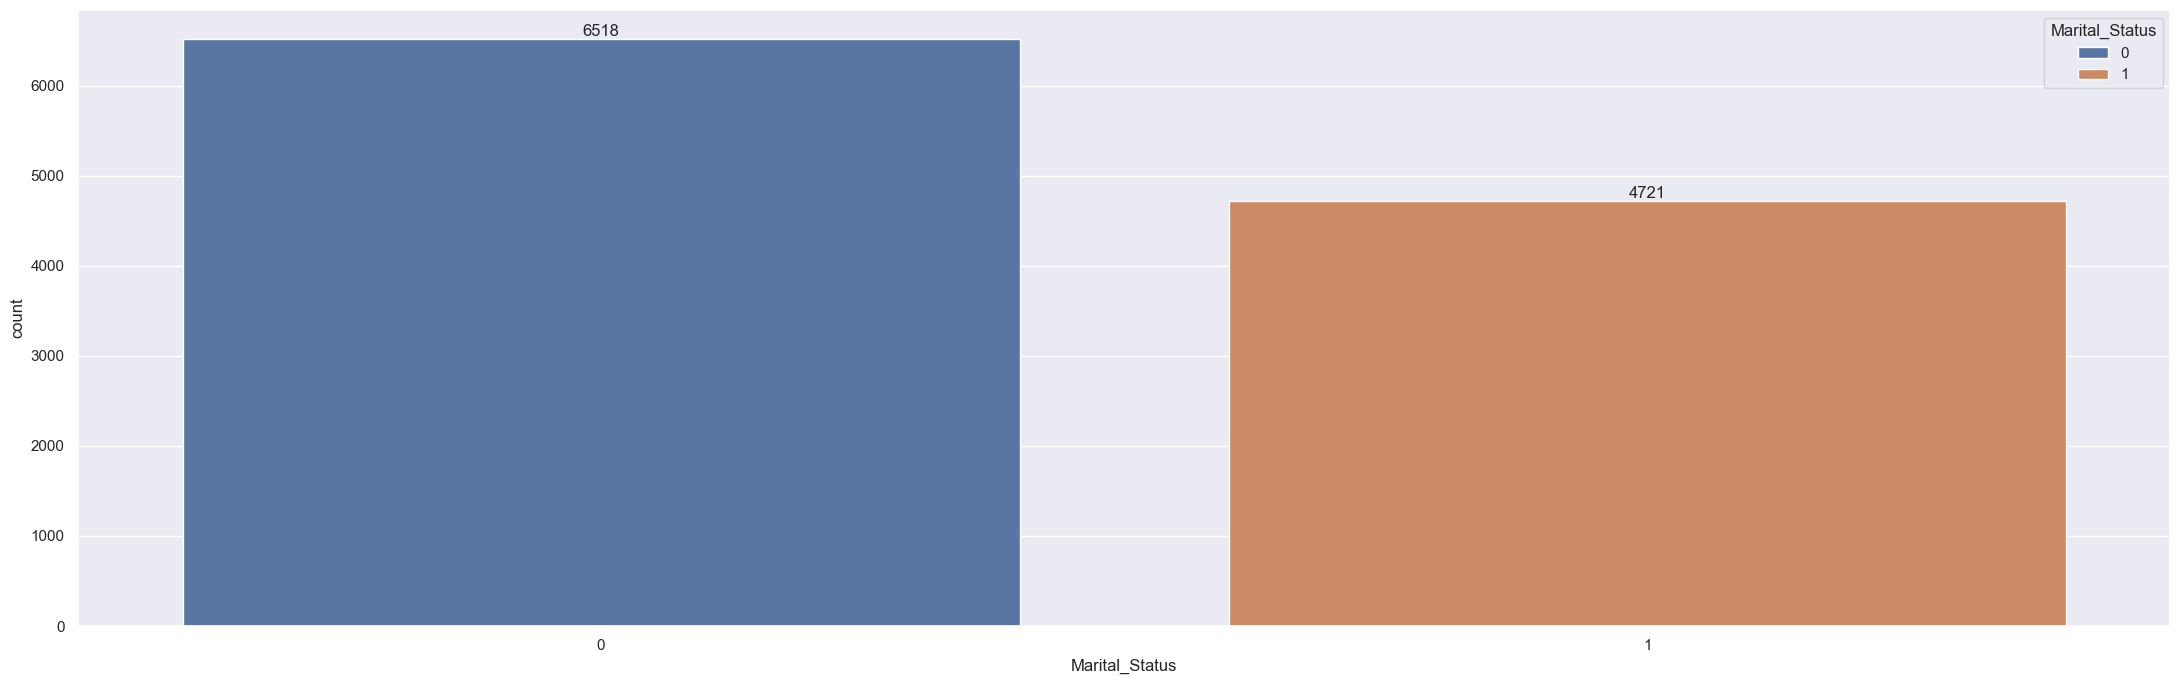

In [30]:
ax = sns.countplot(data = df, x = 'Marital_Status', hue='Marital_Status')
sns.set(rc={'figure.figsize':(7,10)})

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

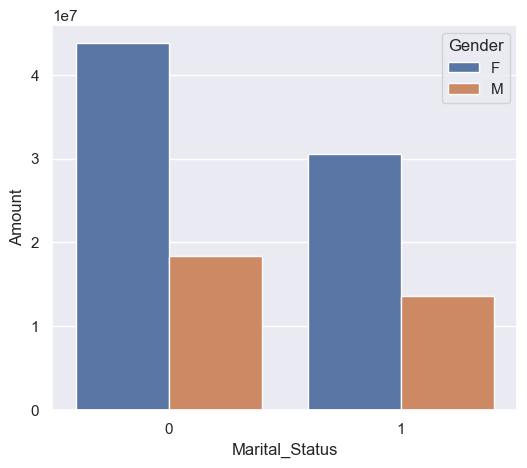

In [31]:
# Total Amount vs Marital_Status
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data= sales_state, x = 'Marital_Status', y = 'Amount', hue= 'Gender')

# conclusion:
*From above graphs we can see that most of the buyers are married (women) and they have high purchasing power*

# occupation

In [32]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [33]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877


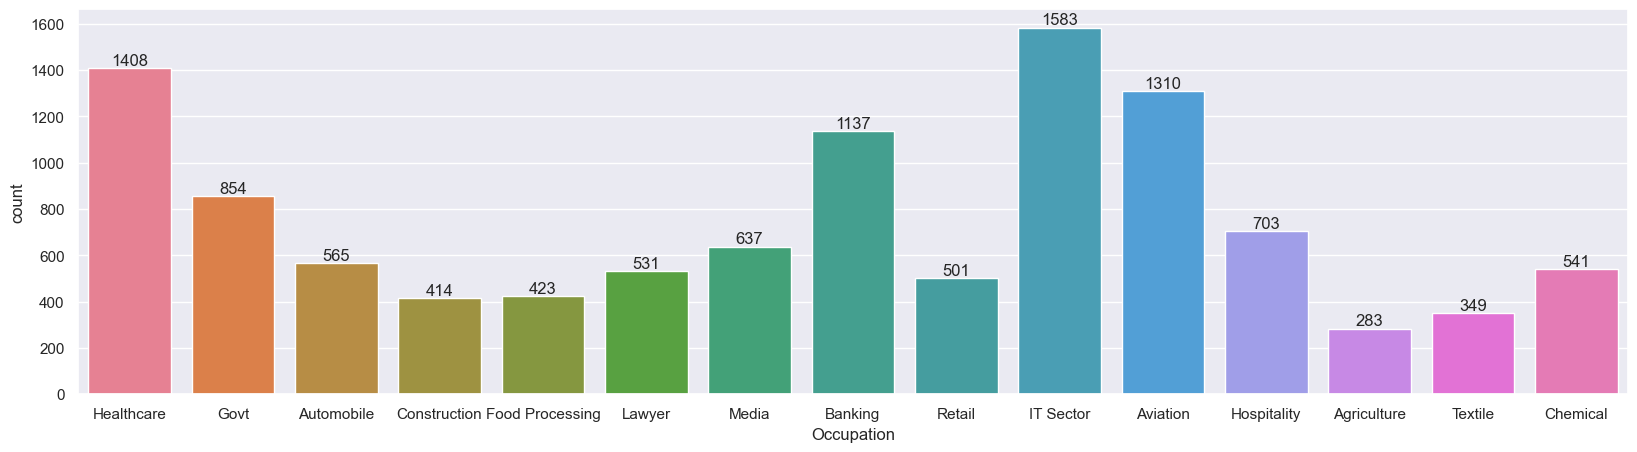

In [34]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Occupation', hue= 'Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

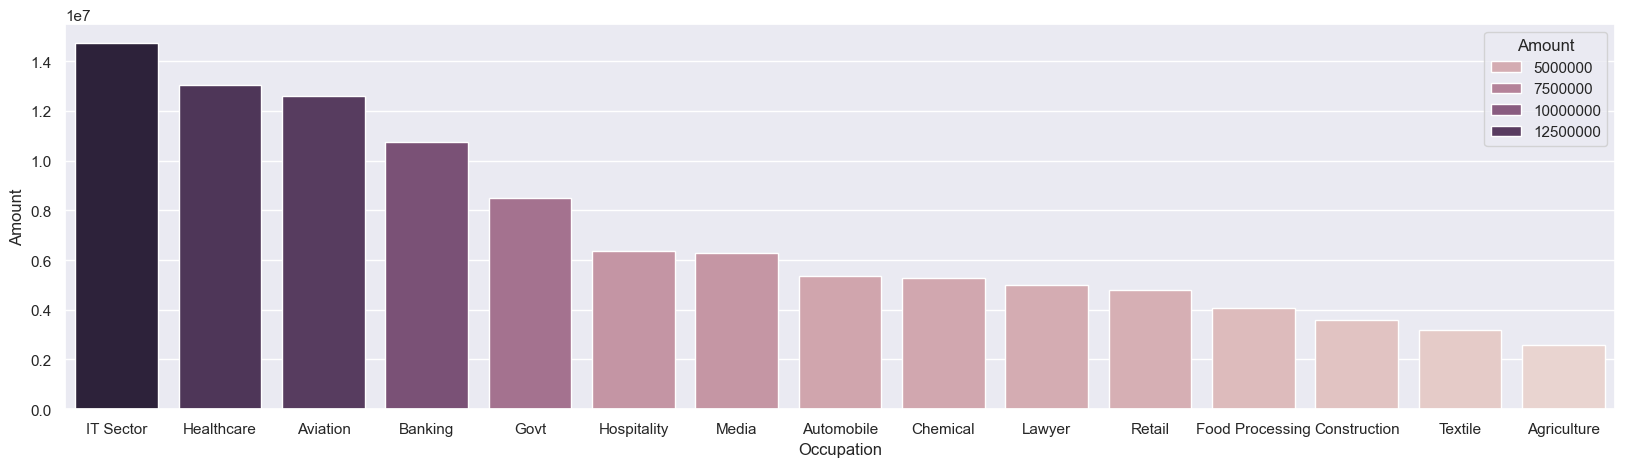

In [35]:
# Total Amount vs Occupation
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount', hue= 'Amount')

## conclusion :
*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

# Product Category

In [36]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [37]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877


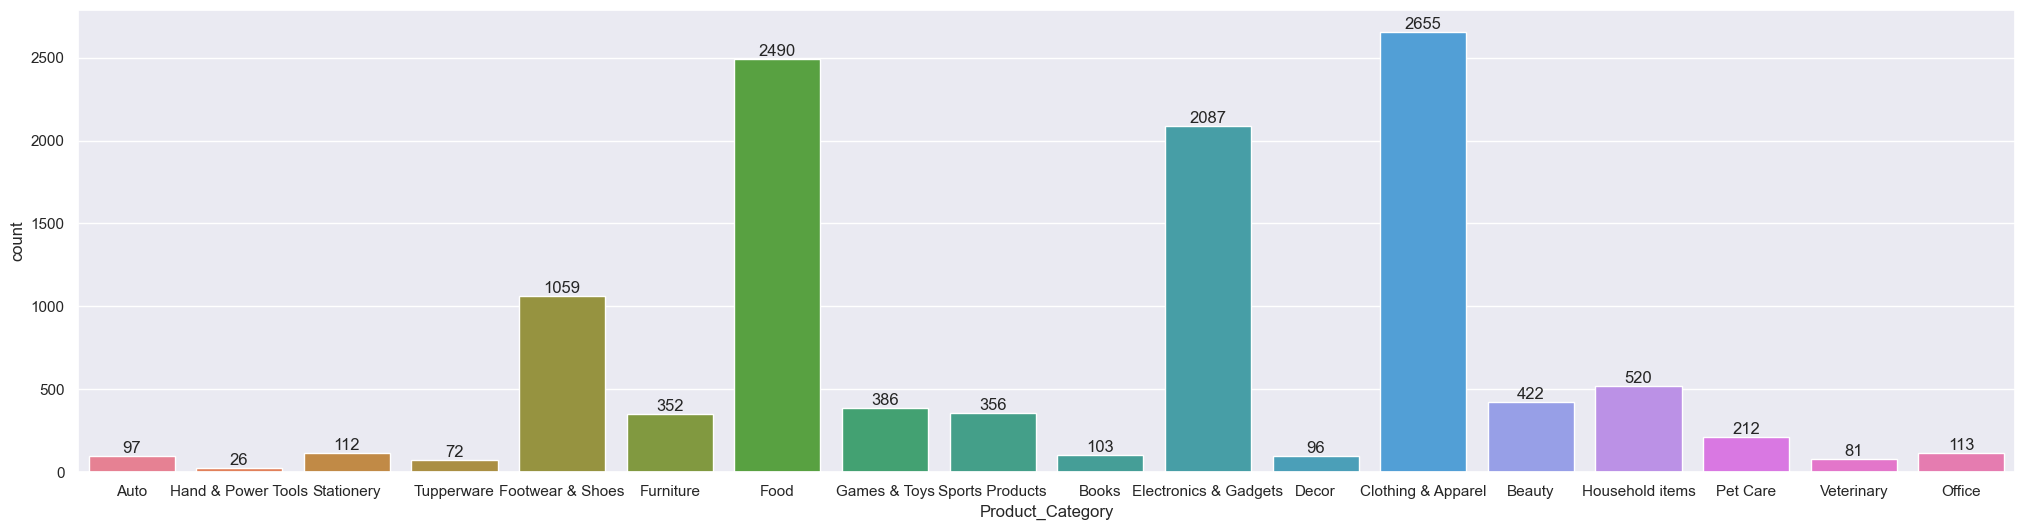

In [38]:
sns.set(rc={'figure.figsize':(25,6)})
ax = sns.countplot(data = df, x = 'Product_Category', hue= 'Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

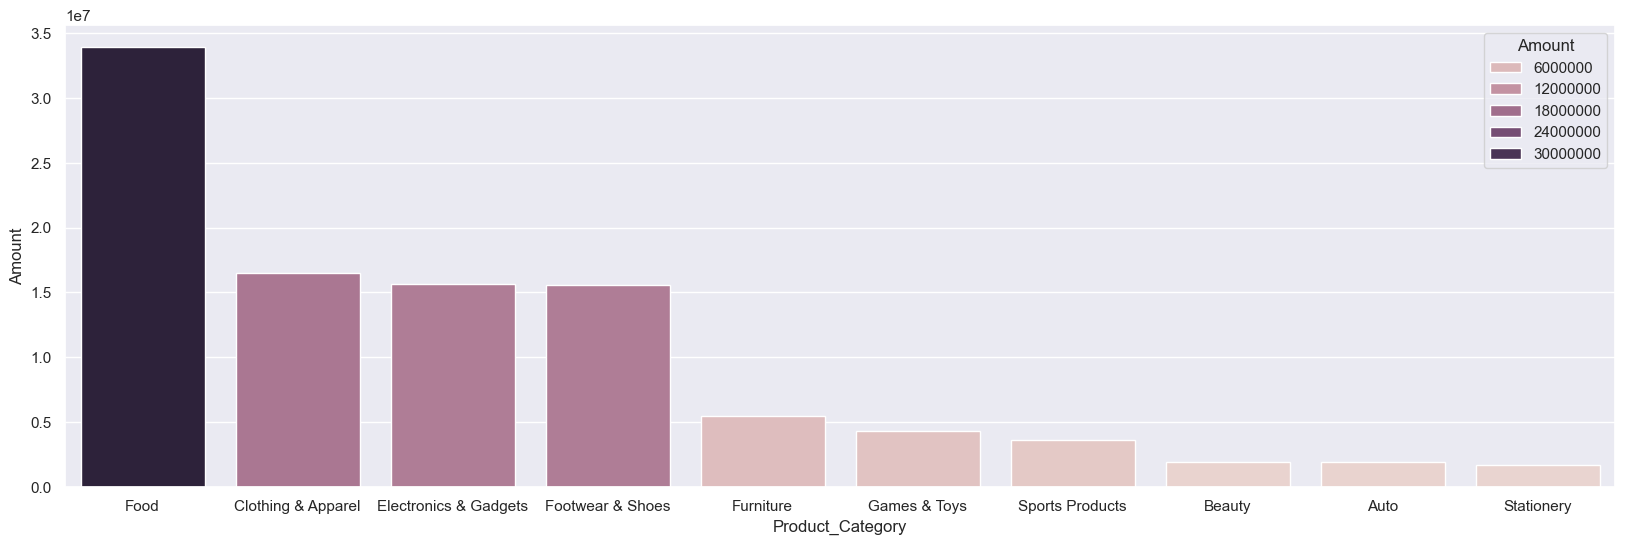

In [39]:
# Total Amount vs Product_Category

sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,6)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount', hue= 'Amount')

# conclusion:
*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

### now, if we want to check the most sold products based on the product_ID

<Axes: xlabel='Product_ID', ylabel='Orders'>

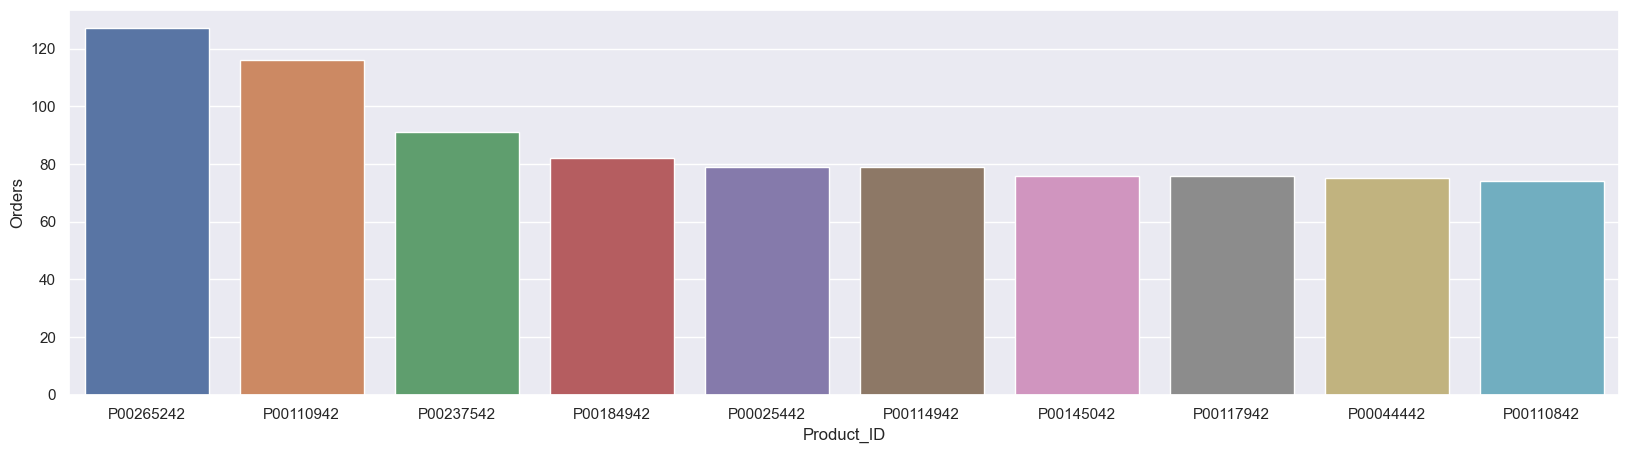

In [40]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders', hue= 'Product_ID')

# final Conclusion:

*Married women age group 26-35 yrs from UP,  Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category*

# Feature Engineering

###  1. Total Spending 

In [41]:
df['Total_Spend'] = df['Orders'] * df['Amount']

In [42]:
df.tail()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Total_Spend
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370,1480
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367,1101
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213,852
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206,618
11250,1002744,Brumley,P00281742,F,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188,564


### 2. Spending_Cateogry

- If the customers spending is large than it shows high and similarly for low

In [44]:
mean_spend = df['Total_Spend'].mean()

df['Spender_Type'] = df['Total_Spend'].apply(
    lambda x: 'High' if x > mean_spend else 'Low'
)

In [55]:
df['High_Spender'] = df['Spender_Type'].map({'Low': 0, 'High': 1})

In [56]:
df.tail()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Total_Spend,Spender_Type,Premium_Customer,High_Spender
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370,1480,Low,0,0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367,1101,Low,0,0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213,852,Low,0,0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206,618,Low,0,0
11250,1002744,Brumley,P00281742,F,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188,564,Low,0,0


# 3.  Premium_Customer

In [51]:
df['Premium_Customer'] = df['Amount'].apply(
    lambda x: 1 if x > df['Amount'].median()
else 0
)

In [54]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Total_Spend,Spender_Type,Premium_Customer
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952,23952,High,1
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934,71802,High,1
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924,71772,High,1
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912,47824,High,1
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877,47754,High,1


# Machine Learning Models
- High Spender Prediction

In [66]:
# Define X and Y
x = df.drop([
    'User_ID',
    'Cust_name',
    'Product_ID',
    'Amount',            # avoid leakage
    'Total_Spend',       # avoid leakage      
    'High_Spender',
    'Spender_Type'
], axis=1)

y = df['High_Spender']

In [67]:
# Encoding (Categorial -> Numerical)
x = pd.get_dummies(x, drop_first=True)

In [69]:
# Train-Test Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


# Training MULTIPLE Models

In [70]:
# 1. Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

In [71]:
# 2. Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

In [72]:
# 3. Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

# Performance Metrics

In [73]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic:", accuracy_score(y_test, y_pred_lr))

print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic: 0.9101423487544484
Decision Tree: 0.896797153024911
Random Forest: 0.9128113879003559


In [74]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1320
           1       0.90      0.89      0.89       928

    accuracy                           0.91      2248
   macro avg       0.91      0.91      0.91      2248
weighted avg       0.91      0.91      0.91      2248



# Feature Importance
- This tells which feature influence spending most

In [76]:
feature_importance = pd.Series(rf.feature_importances_, index=x.columns)
feature_importance.sort_values(ascending=False)

Orders                                 0.385395
Premium_Customer                       0.175954
Age                                    0.064418
Product_Category_Clothing & Apparel    0.033672
Product_Category_Food                  0.030895
                                         ...   
Product_Category_Stationery            0.001670
Product_Category_Decor                 0.001490
State_Telangana                        0.001451
Product_Category_Tupperware            0.001371
Product_Category_Hand & Power Tools    0.000664
Length: 61, dtype: float64

# Confusion Matrix
- This helps explain false positives/negatives

In [77]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_rf)

array([[1227,   93],
       [ 103,  825]])

# Customer Segmentation 

In [78]:
from sklearn.cluster import KMeans

KMeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = KMeans.fit_predict(x)

In [ ]:
df.groupby('Cluster')['Total_Spend'].mean()

# from this we will get:
# Low Spenders
# Medium
# High

Cluster
0    23090.117535
1    24751.525060
2    23649.145958
Name: Total_Spend, dtype: float64

# Final Business Insights

1. Target Customers
- The majority of high-value customers are married females aged 26-35
- This segment shows the highest purchasing power and frequency

   → Business Action:
  - Focus marketing campaigns on this group
  - Personalized ads, festive offers, combo deals

2. High Revenue States
- States like Uttar Pradesh, Maharashtra, and Karnataka contribute the highest revenue

   → Business Action:
  - Increase inventory and logistics in these regions
  - Run region-specific promotions during festive seasons

3. Top Product Categories
- Cateogries such as Foods, Clothings, Electronics and Foot wears related prodcuts generate maximum sales

   → Business Action:
  - Focus on Stocking and Promoting these Categories

4. Occupation-Based Insights
- Customers from IT, Healthcare, and Aviation sectors tend to spend more

   → Business Action:
  - Target this professions with premium offers

5. Customer Segmentation
- Using clustering, customers can be grouped into:
    - cluster 0 -> Low Spenders
    - cluster 1 -> Medium Spenders
    - cluster 2 -> High Spenders

   → Business Action:
  - Low -> Discounts to increase engagement
  - Medium -> Upsell strategies 
  - High -> Premium products and exclusive offers

6. Machine Learning Insights
- The model achieved `91%` accuracy in predicting high spenders
- Random Forest performed best, indicating complex patterns in customer behaviour

   → Business Action:
  - Use model to identify customers in advance